In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sys.path.append("../utility")
from model_performance_regression import regression_model_performance

warnings.filterwarnings("ignore")


In [2]:
data_path = os.path.join("..", "data", "clean_data", "encoded_tree_dataset_final.csv")
df = pd.read_csv(data_path)
df.head()

,State_Province,City,Latitude,Longitude,Elevation,Tree_Name,Tree_Age,Height_Meter,Trunk_Diameter_cm,Canopy_Width_m,...,Inspection_Frequency,Tree_Health_Status,Growth_Rate_m_per_year,Expected_Total_Lifespan_Years,Carbon_Absorption_kg,Survival_Probability,Soil_Type_Clayey,Soil_Type_Loamy,Soil_Type_Saline,Soil_Type_Sandy
0,0.03210,0.03210,23.017811,72.567292,53,0.02000,78,20.71,51.77,14.34,...,2,0,0.306,95,79.97,0.96,1,0,0,0
1,0.03250,0.03250,30.902437,75.867032,247,0.01945,70,17.82,44.54,12.34,...,2,0,0.581,95,68.83,1.00,1,0,0,0
2,0.03380,0.03380,28.621786,77.199431,217,0.02105,94,19.49,48.72,13.49,...,2,0,0.405,95,74.39,0.99,0,0,0,0
3,0.03470,0.03470,24.816504,93.940258,783,0.02070,19,13.63,34.07,9.44,...,2,0,0.570,95,54.78,0.99,0,0,1,0
4,0.03045,0.03045,12.980502,77.596770,920,0.01930,50,19.69,49.22,13.63,...,2,0,0.650,95,75.96,1.00,1,0,0,0


In [4]:
# feature and target separation

soil_cols = [col for col in df.columns if col.startswith("Soil_Type_")]

feature_columns = [
    "Tree_Name",
    "Tree_Age",
    "Height_Meter",
    "Trunk_Diameter_cm",
    "Canopy_Width_m",
    "Root_Depth_m",
    "Growth_Stage",
    "Temperature_C",
    "Rainfall_mm",
    "Humidity_Pct",
    "Wind_Speed_kmh",
    "Solar_Radiation_W_m2",
    "Drought_Index",
    "AQI",
    "PM2_5",
    "PM10",
    "CO_Level",
    "NO2_Level",
    "SO2_Level",
    "Soil_pH",
    "Nitrogen",
    "Phosphorus",
    "Potassium",
    "Organic_Carbon",
    "Leaf_Color",
    "Leaf_Drop_Percentage",
    "Pest_Presence",
    "Disease_Symptoms",
    "Bark_Damage",
    "Root_Condition",
    "Water_Stress_Index",
    "Fungal_Infection",
    "Watering_Frequency",
    "Fertilizer_Usage",
    "Pruning_Count",
    "Treatment_History",
    "Inspection_Frequency"
]

target_column = "Survival_Probability"

X = df[feature_columns]
y = df[target_column]

In [5]:
# Train test split data traing data(80%) and testing data(20%)

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Random Forest Regressor

In [6]:
rfr = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rfr.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

In [7]:
print(f"Traing Score : {rfr.score(X_train,y_train)}")
print(f"Testing Score : {rfr.score(X_test,y_test)}")

Traing Score : 0.9974436028955437
Testing Score : 0.9920989775801673


In [8]:
y_pred_rfr = rfr.predict(X_test)

In [9]:
rfr_model_performance = regression_model_performance(y_test,y_pred_rfr)

Model Performance
------------------------------
MSE  : 0.00025467625267515566
MAE  : 0.011882644878598907
RMSE : 0.01595857928122537
R² Score : 0.9920989775801673


In [11]:
# feature importance 

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rfr.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(30)

,Feature,Importance
25,Leaf_Drop_Percentage,0.141565
30,Water_Stress_Index,0.139390
35,Treatment_History,0.095954
28,Bark_Damage,0.093516
36,Inspection_Frequency,0.086209
32,Watering_Frequency,0.083049
29,Root_Condition,0.071808
26,Pest_Presence,0.063989
12,Drought_Index,0.042111
24,Leaf_Color,0.041877


In [12]:
# Cross Validation
from sklearn.model_selection import cross_val_score

rfr_cv_scores = cross_val_score(
    rfr,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Scores:", rfr_cv_scores)
print("Mean CV Score:", np.mean(rfr_cv_scores))

CV Scores: [0.99182902 0.99216282 0.99197724 0.99184767 0.99156322]
Mean CV Score: 0.991875994653225


In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300,400,500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 5],
    'max_features': ['sqrt', 'log2']
}

rfr_random_search = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    n_iter=10,      
    cv=3,           
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rfr_random_search.fit(X_train, y_train)

print(f"Best Parameters: {rfr_random_search.best_params_}")
print(f"Best CV Score : {rfr_random_search.best_score_}")

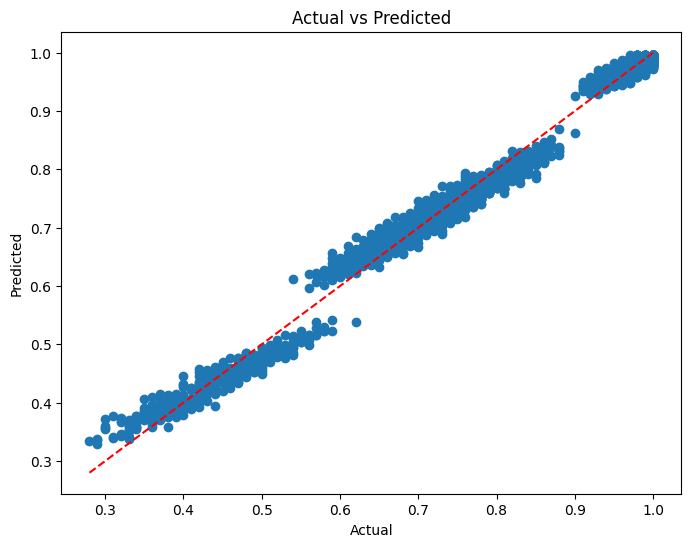

In [13]:
# Actual Value v/s Predicted Value
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            y_pred_rfr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [14]:
df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rfr
})

# =========================
# ERROR CALCULATION
# =========================

# Residual (signed error)
df_results["Error"] = df_results["Actual"] - df_results["Predicted"]

# Absolute Error
df_results["Abs_Error"] = np.abs(df_results["Error"])



print(df_results.head())

       Actual  Predicted     Error  Abs_Error
10650    0.97   0.972569 -0.002569   0.002569
2041     1.00   0.989108  0.010892   0.010892
8668     0.95   0.964918 -0.014918   0.014918
1114     0.98   0.987157 -0.007157   0.007157
13902    0.67   0.698165 -0.028165   0.028165


## XGBoost Regressor

In [15]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
    
)
xgb.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
print(f"Traing Score : {xgb.score(X_train,y_train)}")
print(f"Testing Score : {xgb.score(X_test,y_test)}")

Traing Score : 0.99325332978285
Testing Score : 0.9930885344526363


In [21]:
y_pred_xgb = xgb.predict(X_test)

In [22]:
xgb_model_performance = regression_model_performance(y_test,y_pred_xgb)

Model Performance
------------------------------
MSE  : 0.00022277954074370282
MAE  : 0.011449803931117062
RMSE : 0.014925801175940365
R² Score : 0.9930885344526363


In [19]:
# features importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})
xgb_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
28,Bark_Damage,0.683059
24,Leaf_Color,0.134380
25,Leaf_Drop_Percentage,0.084389
30,Water_Stress_Index,0.049030
26,Pest_Presence,0.017252
29,Root_Condition,0.010161
13,AQI,0.004508
16,CO_Level,0.002626
12,Drought_Index,0.002228
31,Fungal_Infection,0.001958


In [20]:
# cross validation
from sklearn.model_selection import cross_val_score
import numpy as np
xgb_cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Scores:", xgb_cv_scores)
print("Mean CV Score:", np.mean(xgb_cv_scores))

CV Scores: [0.99268268 0.99314537 0.99259969 0.99262508 0.99261446]
Mean CV Score: 0.9927334572422636


In [ ]:
# Hyperparameter Tuning

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb_random_search = RandomizedSearchCV(
    estimator= xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42

)

xgb_random_search.fit(X_train,y_train)

print(f"Best CV Score : {xgb_random_search.best_score_}")
print(f"Best hyperparameters : {xgb_random_search.best_params_}")

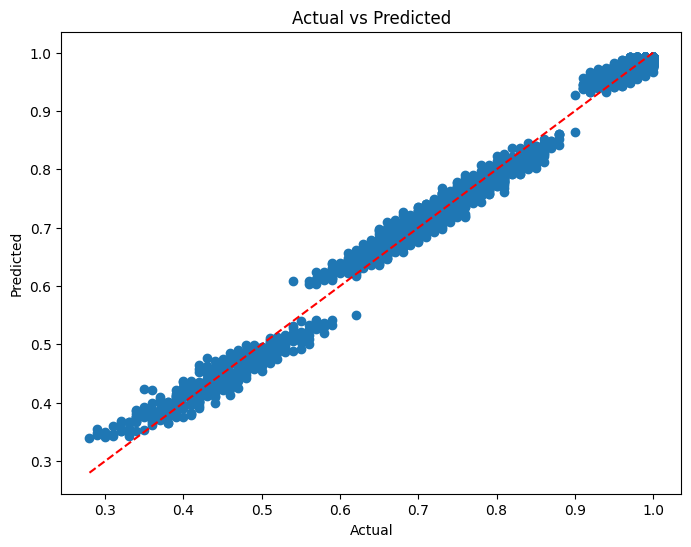

In [23]:
# Actual Value v/s Predicted Value
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            y_pred_xgb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [24]:
xgb_predication = pd.DataFrame(
    {
        "Actual Value " : y_test,
        "Predicated Value " : y_pred_xgb
    }
)
xgb_predication

,Actual Value,Predicated Value
10650,0.97,0.973165
2041,1.00,0.989335
8668,0.95,0.969624
1114,0.98,0.989995
13902,0.67,0.694838
...,...,...
4073,0.65,0.664584
7442,0.94,0.945807
9999,0.99,0.992341
1870,0.68,0.676044


## CatBoostRegressor

In [25]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    l2_leaf_reg=5,
    subsample=0.8,
    verbose=0

)
cat.fit(X_train,y_train)


CatBoostRegressor(depth=6, eval_metric='R2', iterations=1000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, subsample=0.8, verbose=0)

In [26]:
print(f"Traing Score : {cat.score(X_train,y_train)}")
print(f"Testing Score : {cat.score(X_test,y_test)}")

Traing Score : 0.9974479630824629
Testing Score : 0.9969728922691522


In [27]:
y_pred_cat = cat.predict(X_test)

In [28]:
cat_model_performance = regression_model_performance(y_test,y_pred_cat)

Model Performance
------------------------------
MSE  : 9.757375847980972e-05
MAE  : 0.007909073429064554
RMSE : 0.009877943028779307
R² Score : 0.9969728922691522


In [31]:
# cross validation

cat_cv_scores = cross_val_score(
    cat,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


print("CV Scores:", cat_cv_scores)
print("Mean CV Score:", np.mean(cat_cv_scores))

CV Scores: [0.99690868 0.99686323 0.9969278  0.99703183 0.99694768]
Mean CV Score: 0.9969358471744435


In [ ]:
# Hyperparameter Tuning

param_dist = {
    'iterations': [200, 300, 500, 700],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 1, 3, 5],
    'random_strength': [1, 2, 5, 10]
}

cat_random_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

cat_random_search.fit(X_train, y_train)

print(f"Best Parameters : {cat_random_search.best_params_}")

print(f"Best CV Score : {cat_random_search.best_score_}")

In [32]:
# features importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(30))

                 Feature  Importance
26         Pest_Presence   26.436372
25  Leaf_Drop_Percentage   21.746202
33      Fertilizer_Usage    9.968795
24            Leaf_Color    7.298334
29        Root_Condition    5.946550
32    Watering_Frequency    5.865581
35     Treatment_History    5.150515
30    Water_Stress_Index    4.202802
36  Inspection_Frequency    4.060519
28           Bark_Damage    2.801933
12         Drought_Index    1.847956
23        Organic_Carbon    1.817447
34         Pruning_Count    1.575093
31      Fungal_Infection    0.190555
27      Disease_Symptoms    0.164804
8            Rainfall_mm    0.150611
15                  PM10    0.133492
18             SO2_Level    0.132492
17             NO2_Level    0.111336
16              CO_Level    0.108219
14                 PM2_5    0.103897
6           Growth_Stage    0.029517
13                   AQI    0.028584
7          Temperature_C    0.024272
10        Wind_Speed_kmh    0.015723
19               Soil_pH    0.014278
9

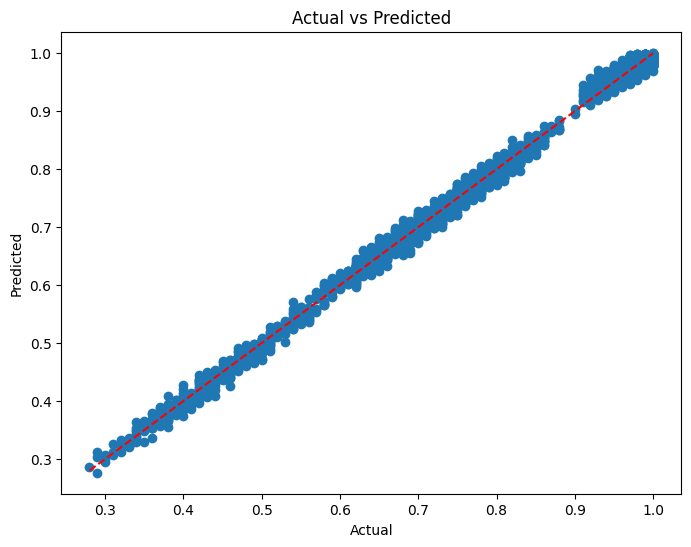

In [33]:
# Actual Value v/s Predicted Value
plt.figure(figsize=(8,6))
plt.scatter(y_test,
            y_pred_cat)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [34]:
cat_predication = pd.DataFrame(
    {
        "Actual Value " : y_test,
        "Predicated Value " : y_pred_cat
    }
)
cat_predication

,Actual Value,Predicated Value
10650,0.97,0.967413
2041,1.00,0.991989
8668,0.95,0.957549
1114,0.98,0.982290
13902,0.67,0.674832
...,...,...
4073,0.65,0.651518
7442,0.94,0.948147
9999,0.99,0.995765
1870,0.68,0.670601


## Model Performance Comparison

In [35]:
results = []


results.append([
    "Random Forest",
    rfr.score(X_train,y_train),
    rfr.score(X_test,y_test),
    rfr_model_performance["R2 Score"],
    rfr_model_performance["MAE"],
    rfr_model_performance["RMSE"]
])

results.append([
    "XGBoost",
    xgb.score(X_train,y_train),
    xgb.score(X_test,y_test),
    xgb_model_performance["R2 Score"],
    xgb_model_performance["MAE"],
    xgb_model_performance["RMSE"]
])

results.append([
    "CatBoost",
    cat.score(X_train,y_train),
    cat.score(X_test,y_test),
    cat_model_performance["R2 Score"],
    cat_model_performance["MAE"],
    cat_model_performance["RMSE"]
])


comparison = pd.DataFrame(
    results,
    columns=["Model","Training Score","Testing Score" ,"R2 Score", "MAE", "RMSE"]
)



## Cross Validation Mean Comparison

In [36]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "CV Mean R2": [
        np.mean(rfr_cv_scores),
        np.mean(xgb_cv_scores),
        np.mean(cat_cv_scores)
    ],
    "CV Std": [
        np.std(rfr_cv_scores),
        np.std(xgb_cv_scores),
        np.std(cat_cv_scores)
    ]
})

cv_comparison.sort_values(
    by="CV Mean R2",
    ascending=False,
    inplace=True
)
cv_comparison.reset_index(drop=True, inplace=True)


## Final Model Comparison Table

In [37]:
final_comparison = comparison.merge(
    cv_comparison,
    on="Model"
)

final_comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,Training Score,Testing Score,R2 Score,MAE,RMSE,CV Mean R2,CV Std
2,CatBoost,0.997448,0.996973,0.996973,0.007909,0.009878,0.996936,0.000056
1,XGBoost,0.993253,0.993089,0.993089,0.011450,0.014926,0.992733,0.000208
0,Random Forest,0.997444,0.992099,0.992099,0.011883,0.015959,0.991876,0.000197


## Best Model Selection

In [38]:
best_model = comparison.sort_values(
    by="Testing Score",
    ascending=False
)

best_model.head(1)

,Model,Training Score,Testing Score,R2 Score,MAE,RMSE
2,CatBoost,0.997448,0.996973,0.996973,0.007909,0.009878


## Save Model

In [ ]:
import joblib

joblib.dump(
    cat,
    "../models/Survival_Prediction_Model.pkl"
)

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "../models/Survival_feature_columns.pkl"
)


['../models/Survival_feature_columns_2.pkl']